# Eksperimen Preprocessing — Credit Card Fraud Dataset
**Nama:** Yogi-Dharma  
**Dataset:** Credit Card Fraud Detection  
**Deskripsi:** Dataset ini berisi 100.000 transaksi kartu kredit dengan label biner `IsFraud` (1 = fraud, 0 = tidak fraud). Tujuan preprocessing ini adalah mempersiapkan data agar siap dilatih oleh model machine learning.

---

## 1. Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
import os

---
## 2. Data Loading

In [12]:
df = pd.read_csv('../credit_card_fraud_dataset_raw.csv')
print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Kolom          : {df.columns.tolist()}')

Dataset berhasil dimuat!
Jumlah baris   : 100,000
Jumlah kolom   : 7
Kolom          : ['TransactionID', 'TransactionDate', 'Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud']


In [13]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [15]:
df.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


### 3.2 Missing Values

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

                 Missing Count  Missing %
TransactionID                0        0.0
TransactionDate              0        0.0
Amount                       0        0.0
MerchantID                   0        0.0
TransactionType              0        0.0
Location                     0        0.0
IsFraud                      0        0.0

Total missing values: 0


### 3.3 Distribusi Target Variable (IsFraud)

Distribusi IsFraud:
  Tidak Fraud (0): 99,000 (99.00%)
  Fraud       (1): 1,000 (1.00%)


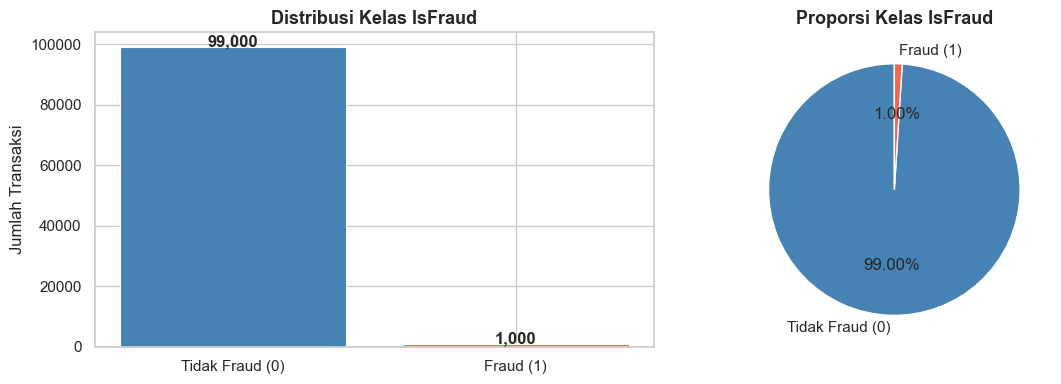


[NOTE] Dataset sangat imbalanced: hanya 1% transaksi fraud!


In [17]:
fraud_counts = df['IsFraud'].value_counts()
fraud_pct = df['IsFraud'].value_counts(normalize=True) * 100

print('Distribusi IsFraud:')
print(f'  Tidak Fraud (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)')
print(f'  Fraud       (1): {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Tidak Fraud (0)', 'Fraud (1)'], fraud_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Kelas IsFraud', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Tidak Fraud (0)', 'Fraud (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporsi Kelas IsFraud', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[NOTE] Dataset sangat imbalanced: hanya 1% transaksi fraud!')

### 3.4 Distribusi Amount

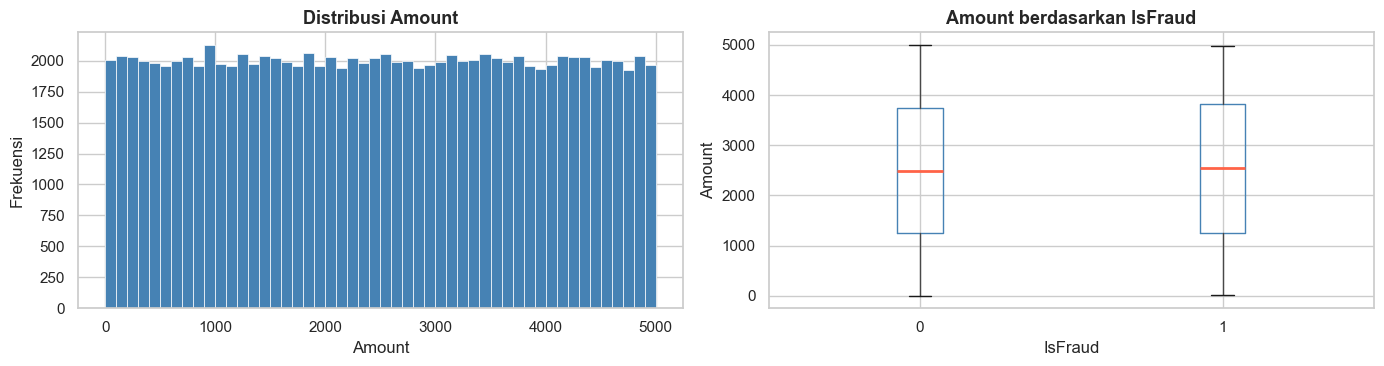

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram Amount
axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Amount', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frekuensi')

# Boxplot Amount by IsFraud
df.boxplot(column='Amount', by='IsFraud', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Amount berdasarkan IsFraud', fontsize=13, fontweight='bold')
axes[1].set_xlabel('IsFraud')
axes[1].set_ylabel('Amount')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 3.5 Distribusi Kolom Kategorikal

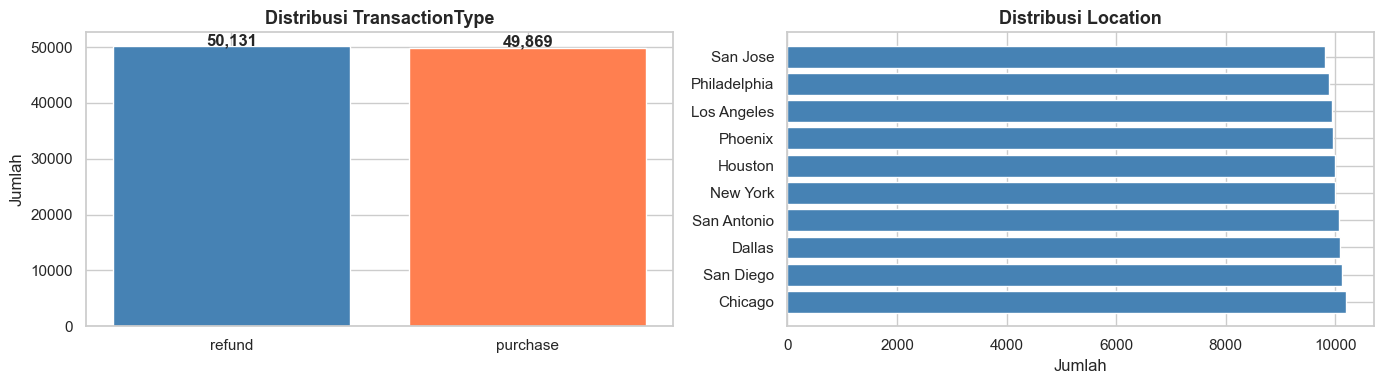

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# TransactionType
tt_counts = df['TransactionType'].value_counts()
axes[0].bar(tt_counts.index, tt_counts.values, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Distribusi TransactionType', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(tt_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Location
loc_counts = df['Location'].value_counts()
axes[1].barh(loc_counts.index, loc_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distribusi Location', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap (Fitur Numerik)

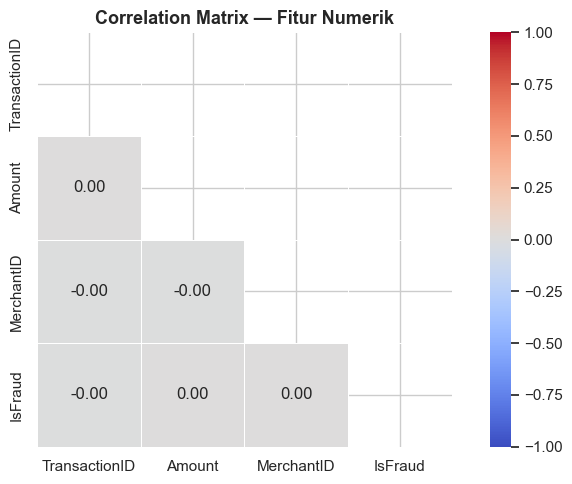

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Preprocessing

In [21]:
df_prep = df.copy()
print('DataFrame disalin. Shape:', df_prep.shape)

DataFrame disalin. Shape: (100000, 7)


### 4.1 Drop Kolom Tidak Diperlukan
`TransactionID` hanya berperan sebagai identifier unik dan tidak memiliki nilai prediktif untuk model.

In [22]:
df_prep = df_prep.drop(columns=['TransactionID'])
print('Kolom TransactionID dihapus.')
print('Kolom tersisa:', df_prep.columns.tolist())

Kolom TransactionID dihapus.
Kolom tersisa: ['TransactionDate', 'Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud']


### 4.2 Handle Missing Values
Berdasarkan EDA, dataset ini tidak memiliki missing values. Namun kita tetap menjalankan penanganan agar pipeline bersifat robust.

In [23]:
missing_total = df_prep.isnull().sum().sum()
print(f'Total missing values: {missing_total}')

if missing_total > 0:
    for col in df_prep.columns:
        if df_prep[col].isnull().sum() > 0:
            if df_prep[col].dtype in [np.float64, np.int64]:
                df_prep[col].fillna(df_prep[col].median(), inplace=True)
                print(f'  {col}: diisi median')
            else:
                df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)
                print(f'  {col}: diisi modus')
else:
    print('Tidak ada missing values — tidak ada tindakan yang diperlukan.')

Total missing values: 0
Tidak ada missing values — tidak ada tindakan yang diperlukan.


### 4.3 Ekstraksi Fitur dari TransactionDate
Kolom `TransactionDate` mengandung informasi waktu yang berguna jika diekstrak menjadi fitur terpisah:
- `transaction_hour` — jam transaksi terjadi
- `transaction_day` — hari dalam bulan
- `transaction_month` — bulan transaksi
- `transaction_dayofweek` — hari dalam minggu (0=Senin)

In [24]:
df_prep['TransactionDate'] = pd.to_datetime(df_prep['TransactionDate'])

df_prep['transaction_hour']      = df_prep['TransactionDate'].dt.hour
df_prep['transaction_day']       = df_prep['TransactionDate'].dt.day
df_prep['transaction_month']     = df_prep['TransactionDate'].dt.month
df_prep['transaction_dayofweek'] = df_prep['TransactionDate'].dt.dayofweek

df_prep = df_prep.drop(columns=['TransactionDate'])

print('Fitur datetime berhasil diekstrak:')
print(df_prep[['transaction_hour','transaction_day','transaction_month','transaction_dayofweek']].head())

Fitur datetime berhasil diekstrak:
   transaction_hour  transaction_day  transaction_month  transaction_dayofweek
0                14                3                  4                      2
1                13               19                  3                      1
2                10                8                  1                      0
3                23               13                  4                      5
4                18               12                  7                      4


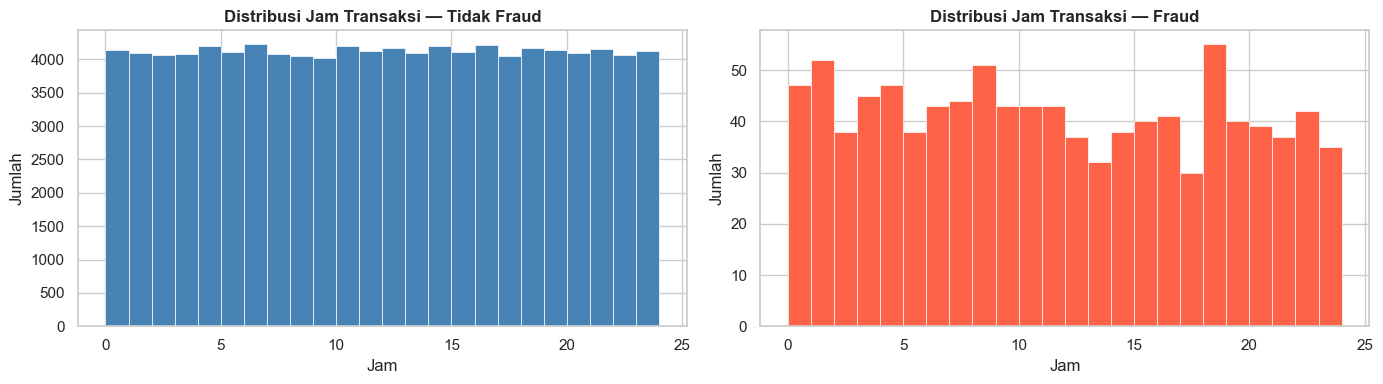

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, fraud_val, label, color in zip(
    axes, [0, 1], ['Tidak Fraud', 'Fraud'], ['steelblue', 'tomato']
):
    subset = df_prep[df_prep['IsFraud'] == fraud_val]['transaction_hour']
    ax.hist(subset, bins=24, range=(0, 24), color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribusi Jam Transaksi — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Jam')
    ax.set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

### 4.4 Encoding Kolom Kategorikal

In [26]:
# --- TransactionType: Binary Encoding ---
# purchase = 1, refund = 0
df_prep['TransactionType'] = df_prep['TransactionType'].map({'purchase': 1, 'refund': 0})
print('TransactionType setelah encoding:')
print(df_prep['TransactionType'].value_counts())

TransactionType setelah encoding:
TransactionType
0    50131
1    49869
Name: count, dtype: int64


In [27]:
# --- Location: Label Encoding ---
le = LabelEncoder()
df_prep['Location'] = le.fit_transform(df_prep['Location'])
print('Location setelah Label Encoding:')
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print(df_prep['Location'].value_counts())

Location setelah Label Encoding:
Mapping: {'Chicago': 0, 'Dallas': 1, 'Houston': 2, 'Los Angeles': 3, 'New York': 4, 'Philadelphia': 5, 'Phoenix': 6, 'San Antonio': 7, 'San Diego': 8, 'San Jose': 9}
Location
0    10193
8    10111
1    10076
7    10062
4     9993
2     9991
6     9960
3     9936
5     9873
9     9805
Name: count, dtype: int64


### 4.5 Feature Scaling (StandardScaler)
StandardScaler diterapkan pada semua fitur kecuali target `IsFraud`, agar model tidak bias terhadap fitur dengan skala besar.

In [28]:
feature_cols = [c for c in df_prep.columns if c != 'IsFraud']

scaler = StandardScaler()
df_prep[feature_cols] = scaler.fit_transform(df_prep[feature_cols])

print('StandardScaler diterapkan pada:', feature_cols)
print()
df_prep[feature_cols].describe().round(4)

StandardScaler diterapkan pada: ['Amount', 'MerchantID', 'TransactionType', 'Location', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek']



,Amount,MerchantID,TransactionType,Location,transaction_hour,transaction_day,transaction_month,transaction_dayofweek
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.7305,-1.7342,-0.9974,-1.5594,-1.6625,-1.6772,-1.5997,-1.5093
25%,-0.8660,-0.8648,-0.9974,-0.8641,-0.7952,-0.8830,-0.7297,-1.0090
50%,-0.0004,0.0046,-0.9974,-0.1687,0.0722,0.0247,0.1403,-0.0085
75%,0.8642,0.8705,1.0026,0.8743,0.7949,0.8189,1.0103,0.9920
max,1.7351,1.7260,1.0026,1.5696,1.6623,1.7266,1.5903,1.4922


---
## 5. Hasil Akhir Preprocessing

In [29]:
print('Shape akhir:', df_prep.shape)
print('Kolom:', df_prep.columns.tolist())
print()
df_prep.head()

Shape akhir: (100000, 9)
Kolom: ['Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek']



,Amount,MerchantID,TransactionType,Location,IsFraud,transaction_hour,transaction_day,transaction_month,transaction_dayofweek
0,1.173161,0.645357,-0.997383,0.874292,0,0.361273,-1.450259,-0.729719,-0.508770
1,0.112740,-1.360085,-0.997383,-1.211743,0,0.216715,0.365086,-1.019723,-1.009016
2,-1.187661,-0.372950,1.002623,-0.168726,0,-0.216958,-0.882963,-1.599730,-1.509262
3,0.705284,1.532047,1.002623,0.178947,0,1.662294,-0.315668,-0.729719,0.991967
4,-1.475326,-0.092396,1.002623,0.526620,0,0.939505,-0.429127,0.140292,0.491722


In [30]:
# Verifikasi tidak ada missing values di akhir
print('Missing values di data hasil preprocessing:')
print(df_prep.isnull().sum())

Missing values di data hasil preprocessing:
Amount                   0
MerchantID               0
TransactionType          0
Location                 0
IsFraud                  0
transaction_hour         0
transaction_day          0
transaction_month        0
transaction_dayofweek    0
dtype: int64


In [31]:
# Simpan hasil preprocessing
output_dir = 'credit_card_fraud_dataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'credit_card_fraud_preprocessing.csv')

df_prep.to_csv(output_path, index=False)
print(f'Dataset preprocessing tersimpan di: {output_path}')
print(f'Shape: {df_prep.shape}')

Dataset preprocessing tersimpan di: credit_card_fraud_dataset_preprocessing\credit_card_fraud_preprocessing.csv
Shape: (100000, 9)
